# AND gate using Adaline 

#### Formal Definiton:

**ADALINE (Adaptive Linear Neuron)** is a single-layer neural network model developed by *Bernard Widrow and Ted Hoff*. 
Unlike the basic Perceptron, which updates weights based on the final thresholded output (0 or 1), ADALINE uses a **Linear Activation Function** to update weights based on the continuous net input before it is thresholded. 
This allows it to **minimize the Mean Squared Error (MSE)** using a process called **Gradient Descent**.

#### Task
This task involves training a mathematical model to find a decision boundary (a line) that separates the "1" case from the "0" cases.

The key difference from a Perceptron: ADALINE calculates how far it was from the right answer (the error) using a continuous value, making the learning process smoother.

---

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display


### 1. Dataset (AND Gate)
Inputs: [x1, x2], Targets: y
| Input $x_1$ | Input $x_2$ | Target ($y$) |
| :---: | :---: | :---: |
| -1 | -1 | -1 |
| -1 | 1 | -1 |
| 1 | -1 | -1 |
| 1 | 1 | 1 |

In [41]:
X = np.array([[-1,-1], [-1,1], [1,-1], [1,1]])
y = np.array([-1, -1, -1, 1])

### 2. Setup ADALINE Parameters
Low learning rate to see movement.
Initialize weights slightly offset from zero to see the initial line.
eta - Learning rate

In [42]:
weights = np.array([0.1, 0.2])
bias = -0.3
eta = 0.05  
epochs = 30

history = []
history.append((weights.copy(), bias))


### 3. Running the Training - Stochastic Gradient Descent


In [43]:
epoch_data = []

for epoch in range(epochs):
    total_epoch_error = 0
    
    for i in range(len(X)):
        # 1. Calculate Net Input (Linear Activation)
        net_input = np.dot(X[i], weights) + bias
        
        # 2. Calculate Continuous Error
        error = y[i] - net_input
        total_epoch_error += error**2 
        
        # 3. Update Weights and Bias (Widrow-Hoff Rule)
        weights += eta * error * X[i]
        bias += eta * error
        
        # 4. Save this state for history and animations
        history.append((weights.copy(), bias))

    # Calculate metrics once the pass through the dataset is complete
    mse = total_epoch_error / len(X)
    
    epoch_data.append({
        "Epoch": epoch,
        "Weights": weights.copy(),
        "Bias": f"{bias:.4f}",
        "MSE": f"{mse:.4f}"
    })

df_results = pd.DataFrame(epoch_data)
display(df_results)

,Epoch,Weights,Bias,MSE
0,0,"[0.1805475, 0.2644475]",-0.3375,0.5635
1,1,"[0.24540548967187498, 0.31620333904687503]",-0.3679,0.4634
2,2,"[0.2976300294929745, 0.35776514339484566]",-0.3927,0.3994
3,3,"[0.33968191541838866, 0.39113936104526553]",-0.4128,0.3587
4,4,"[0.37354262436186364, 0.4179377910262555]",-0.4292,0.3329
5,5,"[0.400807676049334, 0.4394551546804198]",-0.4425,0.3166
6,6,"[0.42276181000131874, 0.45673142982255366]",-0.4533,0.3064
7,7,"[0.44043951963349276, 0.4706019388073321]",-0.4620,0.3001
8,8,"[0.4546737955732373, 0.48173759478436673]",-0.4692,0.2963
9,9,"[0.4661353747712023, 0.49067723868979934]",-0.4750,0.2940



### 4. Setting up the "Canvas"

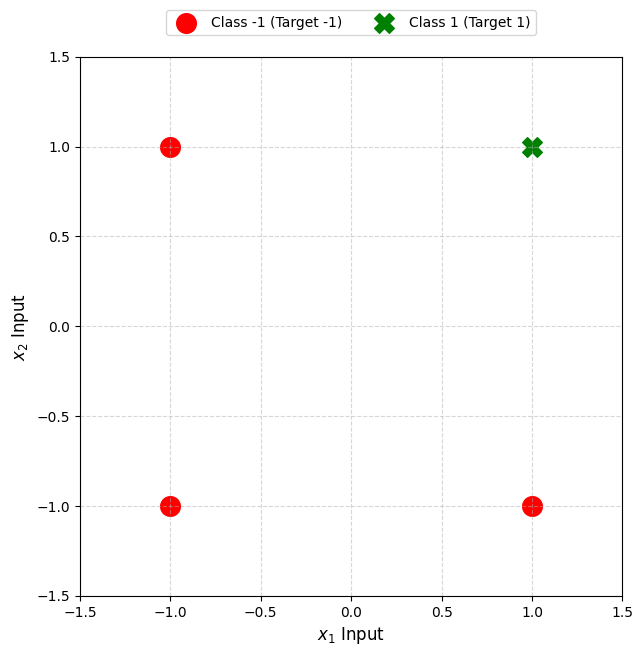

In [44]:
fig, ax = plt.subplots(figsize=(7, 7))

# Plot the static data points once
# Mask the data: Red (Class -1) / Green (Class 1)
class0_mask = (y == -1)
class1_mask = (y == 1)

ax.scatter(X[class0_mask, 0], X[class0_mask, 1], c='red', marker='o', s=200, label='Class -1 (Target -1)')
ax.scatter(X[class1_mask, 0], X[class1_mask, 1], c='green', marker='X', s=200, label='Class 1 (Target 1)')

# Setup plot boundaries (add some padding)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('$x_1$ Input', fontsize=12)
ax.set_ylabel('$x_2$ Input', fontsize=12)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=2)
ax.grid(True, linestyle='--', alpha=0.5)

# Initialize an empty line object that will be updated in the animation
line, = ax.plot([], [], 'b-', lw=3, label='Decision Boundary')

# Text object to display epoch/update info
text_step = ax.text(0.05, 0.05, '', transform=ax.transAxes)

### 5. The Animation Function

In [45]:
def animate(i):
    current_w, current_b = history[i]
    w1, w2 = current_w
    
    x_coords = np.linspace(-1.5, 1.5, 10)
    
    # Division by zero protection
    safe_w2 = w2 if abs(w2) > 1e-6 else 1e-6
    
    # Decision boundary logic
    y_coords = (-current_b - (w1 * x_coords)) / safe_w2
    line.set_data(x_coords, y_coords)
    
    if i == 0:
        text_step.set_text('Status: Initializing Weights')
    else:
        epoch_num = (i - 1) // len(X) 
        sample_num = (i - 1) % len(X)
        text_step.set_text(f'Epoch: {epoch_num} | Sample Update: {sample_num}\n'
                           f'Weights: [{w1:.3f}, {w2:.3f}] | Bias: {current_b:.3f}')
    
    return line, text_step

### 6. Generate and Display the Animation

In [46]:
anim = FuncAnimation(fig, animate, frames=len(history), 
                    interval=100, blit=True, repeat=False)

display(HTML(anim.to_html5_video()))

---

### Using Batch learning

In [47]:
# --- BATCH LEARNING SECTION ---
weights_batch = np.array([0.1, 0.2])
bias_batch = -0.3
history_batch = []
history_batch.append((weights_batch.copy(), bias_batch))

epoch_data_batch = []

for epoch in range(epochs):
    # Accumulators for the entire dataset
    delta_w = np.zeros(weights_batch.shape)
    delta_b = 0
    total_epoch_error = 0
    
    for i in range(len(X)):
        # Calculate Net Input using STATIC weights for this epoch
        net_input = np.dot(X[i], weights_batch) + bias_batch
        
        # Calculate Error for this sample
        error = y[i] - net_input
        total_epoch_error += error**2 
        
        # Accumulate gradients (The "Batch" way)
        delta_w += error * X[i]
        delta_b += error
        
    # --- The Single Update per Epoch ---
    # We use (eta / len(X)) to keep the step size stable regardless of dataset size
    weights_batch += (eta / len(X)) * delta_w
    bias_batch += (eta / len(X)) * delta_b
    
    # Save state for history and animation
    history_batch.append((weights_batch.copy(), bias_batch))

    # Calculate MSE for the epoch
    mse = total_epoch_error / len(X)
    
    # Populate the data frame exactly like the Incremental version
    epoch_data_batch.append({
        "Epoch": epoch,
        "Weights": weights_batch.copy(),
        "Bias": f"{bias_batch:.4f}",
        "MSE": f"{mse:.4f}"
    })

df_batch_results = pd.DataFrame(epoch_data_batch)
display(df_batch_results)

,Epoch,Weights,Bias,MSE
0,0,"[0.12000000000000001, 0.215]",-0.3100,0.5400
1,1,"[0.139, 0.22925]",-0.3195,0.5117
2,2,"[0.15705000000000002, 0.24278750000000002]",-0.3285,0.4862
3,3,"[0.1741975, 0.255648125]",-0.3371,0.4632
4,4,"[0.190487625, 0.26786571875]",-0.3452,0.4424
5,5,"[0.20596324375, 0.2794724328125]",-0.3530,0.4236
6,6,"[0.2206650815625, 0.290498811171875]",-0.3603,0.4067
7,7,"[0.234631827484375, 0.30097387061328124]",-0.3673,0.3914
8,8,"[0.24790023611015624, 0.3109251770826172]",-0.3740,0.3776
9,9,"[0.26050522430464845, 0.32037891822848635]",-0.3803,0.3652


In [48]:
anim_batch = FuncAnimation(fig, animate, frames=len(history_batch), 
                           interval=200, blit=True, repeat=False)

display(HTML(anim.to_html5_video()))

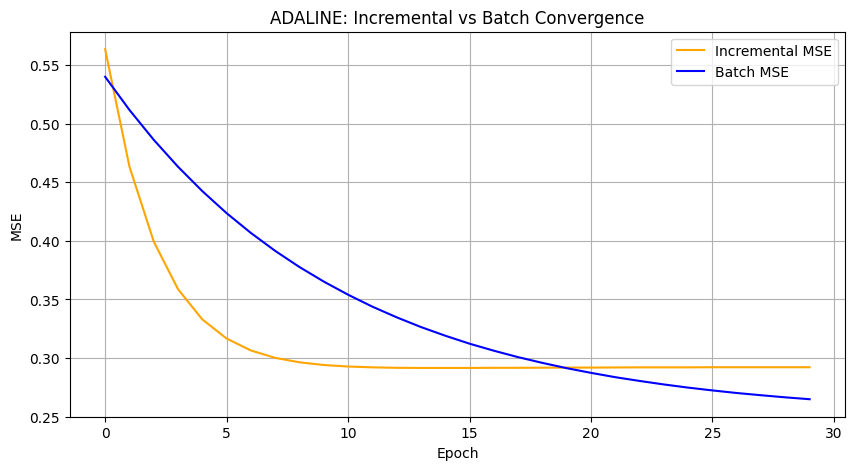

In [49]:
plt.figure(figsize=(10, 5))
plt.plot([float(d['MSE']) for d in epoch_data], label='Incremental MSE', color='orange')
plt.plot([float(d['MSE']) for d in epoch_data_batch], label='Batch MSE', color='blue')
plt.title('ADALINE: Incremental vs Batch Convergence')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()